In [1]:
#Loading Libraries 
!pip install lifelines
import pandas as pd
import numpy as np
import os
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ACTG-Semi Synthetic (Informative)

In [ ]:
#Loading Dataset 
# df = pd.read_csv('/content/actg_semi_info.csv')
# #Pre-processing Features
# x = df.iloc[:,0:23]
# x = SimpleImputer(missing_values=np.nan, strategy='mean').fit_transform(x)
# x = StandardScaler().fit_transform(x)

# n = len(x)
# W = np.array(df['W']) #Treatment Indicator
# y_f = np.array(df['y_f']) #Factual Outcome
# e_f = np.array(df['e_f'])
# t_f = np.array(df['t_f'])
# y_cf = np.array(df['y_cf']) #CounterFactual Outcome
# e_cf = np.array(df['e_cf'])
# t_cf = np.array(df['t_cf']) 
# c_f = np.array(df['c_f']) #Factual censoring time 
# c_cf = np.array(df['c_cf']) #CounterFactual censoring time

# np.random.seed(31415)
# idx = np.arange(0, n)
# np.random.shuffle(idx)
# end_time = max(y_f)
# print("end_time:{}".format(end_time))
# print("event rate:{}".format(sum(e_f) / len(e_f)))
# print("treatment rate:{}".format(sum(W) / len(W)))
# num_examples = int(0.80 * len(e_f))
# print("num_examples:{}".format(num_examples))
# train_idx = idx[0: num_examples]
# split = int((n - num_examples) / 2)
# test_idx = idx[num_examples: num_examples + split]
# valid_idx = idx[num_examples + split: n]

# x_train, x_test, x_val = x[train_idx], x[test_idx], x[valid_idx]
# yf_train, yf_test, yf_val = y_f[train_idx], y_f[test_idx], y_f[valid_idx]
# ycf_train, ycf_test, ycf_val = y_cf[train_idx], y_cf[test_idx], y_cf[valid_idx]
# tf_train, tf_test, tf_val = t_f[train_idx], t_f[test_idx], t_f[valid_idx]
# tcf_train, tcf_test, tcf_val = t_cf[train_idx], t_cf[test_idx], t_cf[valid_idx]
# ef_train, ef_test, ef_val = e_f[train_idx], e_f[test_idx], e_f[valid_idx]
# ecf_train, ecf_test, ecf_val = e_cf[train_idx], e_cf[test_idx], e_cf[valid_idx]
# cf_train, cf_test, cf_val = c_f[train_idx], c_f[test_idx], c_f[valid_idx]
# ccf_train, ccf_test, ccf_val = c_cf[train_idx], c_cf[test_idx], c_cf[valid_idx]
# W_train, W_test, W_val = W[train_idx], W[test_idx], W[valid_idx]

# Synthetic (Informative)

In [8]:
#Loading Dataset 
df = pd.read_csv('/content/data/synthetic_info.csv')
#Pre-processing Features
x = df.iloc[:,0:12]
x = SimpleImputer(missing_values=np.nan, strategy='mean').fit_transform(x)
x = StandardScaler().fit_transform(x)

# #
# df.y_f[df.y_f == 0] = 3
# df.y_cf[df.y_cf == 0] = 3
# df.t_f[df.t_f == 0] = 3
# df.t_cf[df.t_cf == 0] = 3
# df.c_f[df.c_f == 0] = 3
# df.c_cf[df.c_cf == 0] = 3

n = len(x)
W = np.array(df['W']) #Treatment Indicator
y_f = np.array(df['y_f']) #Factual Outcome
e_f = np.array(df['e_f']) #factual event indicator 
t_f = np.array(df['t_f']) #factual time to event
y_cf = np.array(df['y_cf']) #CounterFactual Outcome
e_cf = np.array(df['e_cf']) #counterfactual event indicator
t_cf = np.array(df['t_cf']) #counterfactual time to event
c_f = np.array(df['c_f']) #Factual censoring time 
c_cf = np.array(df['c_cf']) #CounterFactual censoring time

np.random.seed(31415)
idx = np.arange(0, n)
np.random.shuffle(idx)
end_time = max(y_f)
print("end_time:{}".format(end_time))
print("event rate:{}".format(sum(e_f) / len(e_f)))
print("treatment rate:{}".format(sum(W) / len(W)))
num_examples = int(0.70 * len(e_f))
print("num_examples:{}".format(num_examples))
train_idx = idx[0: num_examples]
split = int((n - num_examples) / 2)
test_idx = idx[num_examples: num_examples + split]
valid_idx = idx[num_examples + split: n]

x_train, x_test, x_val = x[train_idx], x[test_idx], x[valid_idx]
yf_train, yf_test, yf_val = y_f[train_idx], y_f[test_idx], y_f[valid_idx]
ycf_train, ycf_test, ycf_val = y_cf[train_idx], y_cf[test_idx], y_cf[valid_idx]
tf_train, tf_test, tf_val = t_f[train_idx], t_f[test_idx], t_f[valid_idx]
tcf_train, tcf_test, tcf_val = t_cf[train_idx], t_cf[test_idx], t_cf[valid_idx]
ef_train, ef_test, ef_val = e_f[train_idx], e_f[test_idx], e_f[valid_idx]
ecf_train, ecf_test, ecf_val = e_cf[train_idx], e_cf[test_idx], e_cf[valid_idx]
cf_train, cf_test, cf_val = c_f[train_idx], c_f[test_idx], c_f[valid_idx]
ccf_train, ccf_test, ccf_val = c_cf[train_idx], c_cf[test_idx], c_cf[valid_idx]
W_train, W_test, W_val = W[train_idx], W[test_idx], W[valid_idx]

end_time:483.51099617901116
event rate:0.4976
treatment rate:0.2292
num_examples:3500


# Surv-CI Informative Model

In [9]:
%cd /content/surv_ci_info

/content/surv_ci_info


In [10]:
#Importing Model
from surv_ci_info import survci_infoBase

  0%|          | 1/200 [00:02<08:15,  2.49s/it]


--------------------------------------------------
Epoch: 0  Train Total Loss: 12.3203 Train elbo Loss: 10.1270  Train ipm Loss: 0.4793 Train mse Loss: 1953.5979  
--------------------------------------------------

--------------------------------------------------
Epoch: 0  Val Total Loss: 11.6655  Val elbo Loss: 10.0592 Val ipm Loss: 0.0849 Val mse Loss: 1563.8541  
--------------------------------------------------


  1%|          | 2/200 [00:04<08:02,  2.44s/it]


--------------------------------------------------
Epoch: 1  Train Total Loss: 12.1295 Train elbo Loss: 10.1271  Train ipm Loss: 0.3050 Train mse Loss: 1849.8946  
--------------------------------------------------

--------------------------------------------------
Epoch: 1  Val Total Loss: 11.4363  Val elbo Loss: 10.0647 Val ipm Loss: 0.0506 Val mse Loss: 1346.2492  
--------------------------------------------------


  2%|▏         | 3/200 [00:07<07:57,  2.43s/it]

...


--------------------------------------------------
Epoch: 6  Train Total Loss: 11.6158 Train elbo Loss: 9.8582  Train ipm Loss: 0.1591 Train mse Loss: 1678.1013  
--------------------------------------------------

--------------------------------------------------
Epoch: 6  Val Total Loss: 11.2700  Val elbo Loss: 9.9983 Val ipm Loss: 0.0688 Val mse Loss: 1237.2959  
--------------------------------------------------


  4%|▍         | 8/200 [00:19<07:41,  2.41s/it]


--------------------------------------------------
Epoch: 7  Train Total Loss: 11.5143 Train elbo Loss: 9.7968  Train ipm Loss: 0.1586 Train mse Loss: 1638.1880  
--------------------------------------------------

--------------------------------------------------
Epoch: 7  Val Total Loss: 11.2712  Val elbo Loss: 9.9899 Val ipm Loss: 0.0791 Val mse Loss: 1241.7977  
--------------------------------------------------


  4%|▍         | 9/200 [00:21<07:38,  2.40s/it]


--------------------------------------------------
Epoch: 8  Train Total Loss: 11.4265 Train elbo Loss: 9.7492  Train ipm Loss: 0.1575 Train mse Loss: 1598.5557  
--------------------------------------------------

--------------------------------------------------
Epoch: 8  Val Total Loss: 11.2722  Val elbo Loss: 9.9868 Val ipm Loss: 0.0838 Val mse Loss: 1243.4948  
--------------------------------------------------

--------------------------------------------------
Epoch: 9  Train Total Loss: 11.3390 Train elbo Loss: 9.7049  Train ipm Loss: 0.1631 Train mse Loss: 1552.6174  
--------------------------------------------------

--------------------------------------------------
Epoch: 9  Val Total Loss: 11.2755  Val elbo Loss: 9.9877 Val ipm Loss: 0.0919 Val mse Loss: 1241.7926  
--------------------------------------------------


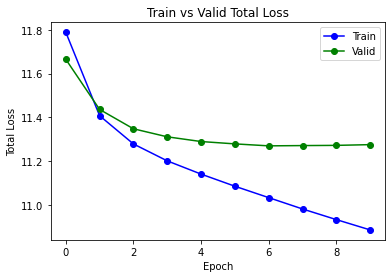

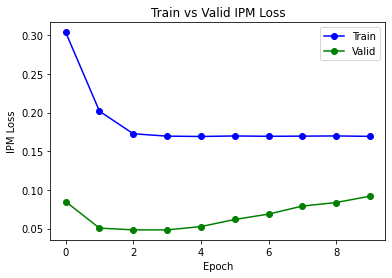

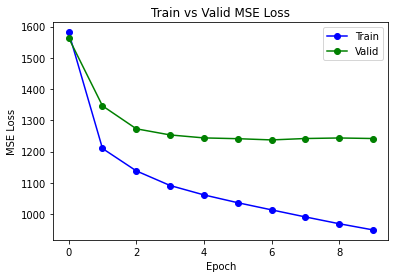

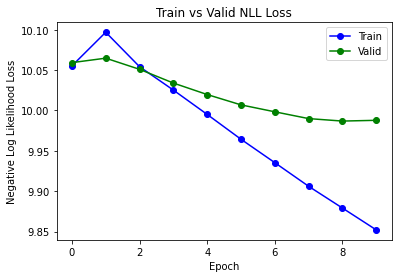

  4%|▍         | 9/200 [00:24<08:49,  2.77s/it]


In [11]:
from sklearn.model_selection import ParameterGrid
param_grid = {'k' : [10], #6,10
              'distribution' : ['LogNormal'],
              'learning_rate' : [3e-4],
              'layers' : [[300,300]],  #[100,100],[300,300]
              'discount': [1],   #Censoring
              'imb_func': ['mmd2_lin'],
              'p_alpha': [5e-1],  #Scaling IPM -Imbalance 2e-2,5e-1
              'p_beta': [1e-3]  #Scaling MSE 7e-6,1e-3
             }
params = ParameterGrid(param_grid)

models = []
for param in params:
    model = survci_infoBase(k = param['k'],
                                 distribution = param['distribution'],
                                 layers = param['layers'],
                                 discount=param['discount'],
                                 imb_func=param['imb_func'],p_alpha=param['p_alpha'],p_beta = param['p_beta'])
    # The fit method is called to train the model
    model.fit(x_train, tf_train,cf_train, ef_train,W_train, iters = 200,learning_rate = param['learning_rate'])
    models.append([model.compute_ci(x_val,tf_val,cf_val,ef_val,W_val), model.compute_mse_factual(x_val,tf_val,cf_val,ef_val,W_val),model]) #hyperparameter selection based on Factual MSE 

In [12]:
#Hyperparameter Selection

cis = [] #Concordance Index for all the models
mse_f = [] #Mean Square Error computed on Factual Data for all the models 
for i in range(len(models)):
   cis.append(models[i][0])
   mse_f.append(float(models[i][1]))

#Normalizing the RMSE 
min_2, max_2 = 0, 1
rmse_f = np.sqrt(mse_f)
rmse_f_std = (np.array(rmse_f) - min(rmse_f)) / (max(rmse_f) - min(rmse_f))
rmse_f_scaled = rmse_f_std * (max_2 - min_2) + min_2

temp_metric = cis - rmse_f_scaled  
max_ci = max(cis)
min_mse = min(mse_f)
max_metric = max(temp_metric)

for i in range(len(models)):
  if models[i][0] == max_ci and models[i][1] == min_mse:
    best_model = models[i]
  elif temp_metric[i] == max_metric:
    best_model = models[i]

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:12: RuntimeWarning: invalid value encountered in true_divide
  if sys.path[0] == '':


In [ ]:
#Saving the Best Model
if not os.path.isdir('./Models'):
        os.makedirs('./Models')
#np.save('Models/actg_semi_info_best_model.npy',best_model)
np.save('Models/synthetic_info_best_model.npy',best_model)

In [13]:
#best_model = np.load('Models/actg_semi_info_best_model.npy', allow_pickle=True)
model = best_model[2]
#Best Hyperparameters 
print('Number of Parametric Distibutions (K):', model.k)
print('Layers:', model.layers)
print('Disribution:', model.dist)
print('Imb Loss:', model.imb_func)
print('Scaling Parameter for IPM-Imbalance:', model.p_alpha)
print('Scaling MSE Loss:', model.p_beta)
print('Scaling ELBO_censored Loss:',model.discount)

Number of Parametric Distibutions (K): 10
Layers: [300, 300]
Disribution: LogNormal
Imb Loss: mmd2_lin
Scaling Parameter for IPM-Imbalance: 0.5
Scaling MSE Loss: 0.001
Scaling ELBO_censored Loss: 1


# Testing

In [14]:
from surv_ci_info.utilities import auc
import torch
#Distibution Parameters
shapef_co,scalef_co,logitsf_co, shapef_tr,scalef_tr,logitsf_tr,shapef_co_c,scalef_co_c,logitsf_co_c,shapef_tr_c,scalef_tr_c,logitsf_tr_c= model.predict_dist_parameters(x_test,torch.from_numpy(W_test)) #Predicted Factual Parameters 
shapecf_co,scalecf_co,logitscf_co, shapecf_tr,scalecf_tr,logitscf_tr,shapecf_co_c,scalecf_co_c,logitscf_co_c,shapecf_tr_c,scalecf_tr_c,logitscf_tr_c = model.predict_dist_parameters(x_test,torch.from_numpy(1-W_test)) #Predicted Counter Factual Parameters 

t_pred_f_co = auc(model, torch.from_numpy(yf_test),shapef_co,scalef_co, logitsf_co ) #Predicted Factual Outcome (Treatment (w) = 0)
t_pred_f_tr = auc(model,torch.from_numpy(yf_test),shapef_tr,scalef_tr, logitsf_tr) #Predicted Factual Outcome (Treatment(W) = 1)
t_pred_cf_co = auc(model, torch.from_numpy(yf_test),shapecf_co,scalecf_co,logitscf_co ) #Predcited CounterFactual Outcome (Treatment (W)= 1 )
t_pred_cf_tr = auc(model,torch.from_numpy(yf_test),shapecf_tr,scalecf_tr,logitscf_tr)
c_pred_f_co = auc(model, torch.from_numpy(yf_test),shapef_co_c,scalef_co_c, logitsf_co_c ) #Predicted Factual Outcome (Treatment (w) = 0)
c_pred_f_tr = auc(model,torch.from_numpy(yf_test),shapef_tr_c,scalef_tr_c, logitsf_tr_c) #Predicted Factual Outcome (Treatment(W) = 1)
c_pred_cf_co = auc(model, torch.from_numpy(yf_test),shapecf_co_c,scalecf_co_c,logitscf_co_c ) #Predcited CounterFactual Outcome (Treatment (W)= 1 )
c_pred_cf_tr = auc(model,torch.from_numpy(yf_test),shapecf_tr_c,scalecf_tr_c,logitscf_tr_c)
y_pred_f_co = ef_test[W_test==0]*t_pred_f_co.detach().numpy() + (1-ef_test[W_test==0])*c_pred_f_co.detach().numpy()
y_pred_f_tr = ef_test[W_test==1]*t_pred_f_tr.detach().numpy() + (1-ef_test[W_test==1])*c_pred_f_tr.detach().numpy()
y_pred_cf_co = ecf_test[W_test==1]*t_pred_cf_co.detach().numpy() + (1-ecf_test[W_test==1])*c_pred_cf_co.detach().numpy()
y_pred_cf_tr = ecf_test[W_test==0]*t_pred_cf_tr.detach().numpy() + (1-ecf_test[W_test==0])*c_pred_cf_tr.detach().numpy()

Concordance Index

In [15]:
from surv_ci_info.utilities import softmax_out, sample_lognormal, sample_weibull
from lifelines.utils import concordance_index
treated_idx = np.where(W_test>0)[0]                        
control_idx = np.where(W_test<1)[0]
c_index_co = concordance_index(event_times=yf_test[control_idx],predicted_scores=y_pred_f_co,event_observed=ef_test[control_idx])
c_index_tr = concordance_index(event_times=yf_test[treated_idx],predicted_scores=y_pred_f_tr,event_observed=ef_test[treated_idx])
ci_index = (c_index_co + c_index_tr) * 0.5
print('CI Index - Control', c_index_co)
print('CI Index - Treated', c_index_tr)
print('Avg CI ', ci_index)

CI Index - Control 0.8314437597026861
CI Index - Treated 0.7593596695068422
Avg CI  0.7954017146047642


In [ ]:
# #Bootstrapping for CI
# ci_all = []
# ci_control = []
# ci_treated = []
# for _ in range(1000):
#   ind = np.random.randint(0, x_test.shape[0], x_test.shape[0])
#   yf = yf_test[ind]
#   #tcf = tcf_test[ind]
#   ef = ef_test[ind]
#   x = x_test[ind]
#   w = W_test[ind]

#   #Distibution Parameters
#   #shapef_co,scalef_co,logitsf_co, shapef_tr,scalef_tr,logitsf_tr,_,_,_,_,_,_ = model.predict_dist_parameters(x,torch.from_numpy(w))  #Predicted Factual Parameters 
#   shapef_co,scalef_co,logitsf_co, shapef_tr,scalef_tr,logitsf_tr,shapef_co_c,scalef_co_c,logitsf_co_c,shapef_tr_c,scalef_tr_c,logitsf_tr_c= model.predict_dist_parameters(x,torch.from_numpy(w)) #Predicted Factual Parameters 
#   #shapecf_co,scalecf_co,logitscf_co, shapecf_tr,scalecf_tr,logitscf_tr,shapecf_co_c,scalecf_co_c,logitscf_co_c,shapecf_tr_c,scalecf_tr_c,logitscf_tr_c = model.predict_dist_parameters(x,torch.from_numpy(1-w)) #Predicted Counter Factual Parameters 

#   #shapecf_co,scalecf_co,logitscf_co, shapecf_tr,scalecf_tr,logitscf_tr = model.predict_dist_parameters(x,torch.from_numpy(1-w))  #Predicted Counter Factual Parameters 

#   #Factual Outcomes 
#   t_pred_f_co = auc(model, torch.from_numpy(yf),shapef_co,scalef_co, logitsf_co ) #Predicted Factual Outcome (Treatment (w) = 0)
#   t_pred_f_tr = auc(model,torch.from_numpy(yf),shapef_tr,scalef_tr, logitsf_tr) #Predicted Factual Outcome (Treatment(W) = 1)
#   c_pred_f_co = auc(model, torch.from_numpy(yf),shapef_co_c,scalef_co_c, logitsf_co_c ) #Predicted Factual Outcome (Treatment (w) = 0)
#   c_pred_f_tr = auc(model,torch.from_numpy(yf),shapef_tr_c,scalef_tr_c, logitsf_tr_c)
#   y_pred_f_co = ef[w==0]*t_pred_f_co.detach().numpy() + (1-ef[w==0])*c_pred_f_co.detach().numpy()
#   y_pred_f_tr = ef[w==1]*t_pred_f_tr.detach().numpy() + (1-ef[w==1])*c_pred_f_tr.detach().numpy()
#   #y_pred_cf_co = ecf[w==1]*t_pred_cf_co.detach().numpy() + (1-ecf[W_test==1])*c_pred_cf_co.detach().numpy()
#   #y_pred_cf_tr = ecf[w==0]*t_pred_cf_tr.detach().numpy() + (1-ecf[W_test==0])*c_pred_cf_tr.detach().numpy()


#   treated_idx = np.where(w>0)[0]                        
#   control_idx = np.where(w<1)[0]
#   c_index_co = concordance_index(event_times=yf[control_idx],predicted_scores=y_pred_f_co,event_observed=ef[control_idx])
#   c_index_tr = concordance_index(event_times=yf[treated_idx],predicted_scores=y_pred_f_tr,event_observed=ef[treated_idx])

#   ci_index = (c_index_co + c_index_tr) * 0.5
#   ci_all.append(ci_index)
#   ci_control.append(c_index_co)
#   ci_treated.append(c_index_tr)



# # 95% confidence intervals
# def confidence_interval(metric):
#   lower =  np.percentile(metric, 2.5)
#   median = np.percentile(metric, 50)
#   upper =  np.percentile(metric, 97.5)  
#   return median,lower,upper

# median,lower,upper = confidence_interval(ci_all)
# print('Concordance Index_Avg:', "{} ({},{})".format(median,lower, upper))
# median_0,lower_0,upper_0 = confidence_interval(ci_control)
# print('Concordance Index_Control:', "{} ({},{})".format(median_0,lower_0, upper_0))
# median_1,lower_1,upper_1 = confidence_interval(ci_treated)
# print('Concordance Index_Treated:', "{} ({},{})".format(median_1,lower_1, upper_1))

Treatment Effect

In [16]:
#Ground Truth Inidivdual Treatment Effect (ITE)
emp_ite_a = yf_test[W_test==1] - ycf_test[W_test==1]
emp_ite_b = ycf_test[W_test==0] - yf_test[W_test==0] 
emp_ite = np.concatenate((emp_ite_a, emp_ite_b), axis=0)

#Predicted ITE
pred_ite_a = y_pred_f_tr - y_pred_cf_co #Factual_Treatment=1
pred_ite_b = y_pred_cf_tr - y_pred_f_co #Factual_Treatment=0
pred_ite = np.concatenate((pred_ite_a, pred_ite_b), axis=0)

#Average Treatment Effect Metric
emp_ate = np.mean(emp_ite)
pred_ate =np.mean(pred_ite)
epsilon_ate = np.abs(emp_ate-pred_ate)

print("Ground Truth ATE: ", np.round(emp_ate, 4))
print("Predicted ATE: ", np.round(pred_ate,4))
print("Epsilon ATE: ", np.round(epsilon_ate, 4))

Ground Truth ATE:  -0.9195
Predicted ATE:  27.8619
Epsilon ATE:  28.7814


PEHE

In [17]:
#Bootstrapping

pehe_all = []
for _ in range(1000):
  ind = np.random.randint(0, x_test.shape[0], x_test.shape[0])
  
  yf = yf_test[ind]
  ycf = ycf_test[ind]

  ef = ef_test[ind]
  ecf = ecf_test[ind]
  x = x_test[ind]
  w = W_test[ind]

  #Ground Truth Individual Treatment Effect (ITE)
  emp_ite_a = yf[w==1] - ycf[w==1]
  emp_ite_b = ycf[w==0] - yf[w==0] 
  emp_ite = np.concatenate((emp_ite_a, emp_ite_b), axis=0)
  
  #Distibution Parameters 
  shapef_co,scalef_co,logitsf_co, shapef_tr,scalef_tr,logitsf_tr,shapef_co_c,scalef_co_c,logitsf_co_c,shapef_tr_c,scalef_tr_c,logitsf_tr_c= model.predict_dist_parameters(x,torch.from_numpy(w)) #Predicted Factual Parameters 
  shapecf_co,scalecf_co,logitscf_co, shapecf_tr,scalecf_tr,logitscf_tr,shapecf_co_c,scalecf_co_c,logitscf_co_c,shapecf_tr_c,scalecf_tr_c,logitscf_tr_c = model.predict_dist_parameters(x,torch.from_numpy(1-w)) #Predicted Counter Factual Parameters 


  #Factual Outcomes 
  t_pred_f_co = auc(model, torch.from_numpy(yf),shapef_co,scalef_co, logitsf_co ) #Predicted Factual Outcome (Treatment (w) = 0)
  t_pred_f_tr = auc(model,torch.from_numpy(yf),shapef_tr,scalef_tr, logitsf_tr) #Predicted Factual Outcome (Treatment(W) = 1)
  t_pred_cf_co = auc(model, torch.from_numpy(yf),shapecf_co,scalecf_co, logitscf_co ) #Predicted CounterFactual Outcome (Treatment (w) = 0)
  t_pred_cf_tr = auc(model,torch.from_numpy(yf),shapecf_tr,scalecf_tr, logitscf_tr)
  c_pred_f_co = auc(model, torch.from_numpy(yf),shapef_co_c,scalef_co_c, logitsf_co_c ) #Predicted Factual Outcome (Treatment (w) = 0)
  c_pred_f_tr = auc(model,torch.from_numpy(yf),shapef_tr_c,scalef_tr_c, logitsf_tr_c)
  c_pred_cf_co = auc(model, torch.from_numpy(yf),shapecf_co_c,scalecf_co_c, logitscf_co_c ) #Predicted Counteractual Outcome (Treatment (w) = 0)
  c_pred_cf_tr = auc(model,torch.from_numpy(yf),shapecf_tr_c,scalecf_tr_c, logitscf_tr_c)
  y_pred_f_co = ef[w==0]*t_pred_f_co.detach().numpy() + (1-ef[w==0])*c_pred_f_co.detach().numpy()
  y_pred_f_tr = ef[w==1]*t_pred_f_tr.detach().numpy() + (1-ef[w==1])*c_pred_f_tr.detach().numpy()
  y_pred_cf_co = ecf[w==1]*t_pred_cf_co.detach().numpy() + (1-ecf[w==1])*c_pred_cf_co.detach().numpy()
  y_pred_cf_tr = ecf[w==0]*t_pred_cf_tr.detach().numpy() + (1-ecf[w==0])*c_pred_cf_tr.detach().numpy()

  pred_ite_a = y_pred_f_tr - y_pred_cf_co #Factual_Treatment=1
  pred_ite_b = y_pred_cf_tr - y_pred_f_co #Factual_Treatment=0
  pred_ite = np.concatenate((pred_ite_a, pred_ite_b), axis=0)

  emp_ate = np.mean(emp_ite)
  pred_ate =np.mean(pred_ite)

  #PEHE Metric
  pehe = (emp_ite-pred_ite)**2
  pehe_all.append(np.round(np.sqrt(np.mean(pehe)), 4))  #\epsilon_{pehe}

# 95% confidence intervals
def confidence_interval(metric):
  lower =  np.percentile(metric, 2.5)
  median = np.percentile(metric, 50)
  upper =  np.percentile(metric, 97.5)  
  return median,lower,upper

median,lower,upper = confidence_interval(pehe_all)
print('PEHE:', "{} ({},{})".format(median,lower, upper))

PEHE: 56.4668 (49.6516875,61.883912499999994)


Parametric Hazard Ratio

In [18]:
def lognormal_pdf(mu, sigma, t):
  a = 1/(t*sigma*np.sqrt(2*np.pi))
  b = ((np.log(t) - mu)**2)/(2*(sigma**2))
  pdf = a*np.exp(-b)
  return pdf

def lognormal_surv(mu,sigma,t):
  s = (np.log(t) - mu)/ sigma*np.sqrt(2)
  s = 0.5 - 0.5*np.array(torch.erf(torch.from_numpy(s)))
  return s

def compute_HR(T0,T1,mu0, sigma0, mu1, sigma1):
  pdf_0 = lognormal_pdf(mu0, np.exp(sigma0), T0)
  pdf_1 = lognormal_pdf(mu1, np.exp(sigma1), T1)
  surv_0 = lognormal_surv(mu0,np.exp(sigma0), T0)
  surv_1 = lognormal_surv(mu1, np.exp(sigma1), T1)
  hr = (pdf_1/pdf_0)*(surv_0/surv_1)
  return hr
  
shapef_0, scalef_0 = softmax_out(shapef_co,scalef_co, logitsf_co)
shapef_1, scalef_1= softmax_out(shapef_tr,scalef_tr,logitsf_tr)
shapecf_0, scalecf_0 = softmax_out(shapecf_co,scalecf_co, logitscf_co)
shapecf_1, scalecf_1 = softmax_out(shapecf_tr,scalecf_tr,logitscf_tr)

shape_co = np.concatenate((shapef_0.detach().numpy(), shapecf_0.detach().numpy()), axis=0)
scale_co =  np.concatenate((scalef_0.detach().numpy(), scalecf_0.detach().numpy()), axis=0)
shape_tr = np.concatenate((shapef_1.detach().numpy(), shapecf_1.detach().numpy()), axis=0)
scale_tr = np.concatenate((scalef_1.detach().numpy(), scalecf_1.detach().numpy()), axis=0)


T_0_pred = torch.cat((t_pred_f_co, t_pred_cf_co), dim=0)
T_1_pred = torch.cat((t_pred_f_tr, t_pred_cf_tr), dim=0)

hr_pred = compute_HR(T_0_pred.detach().numpy(), T_1_pred.detach().numpy(), shape_co, scale_co, shape_tr, scale_tr)
print('Hazard Ratio- median:', "{}".format(np.round(np.median(hr_pred),4)))
print('Hazard Ratio- mean:', "{}".format(np.round(np.mean(hr_pred),4)))

Hazard Ratio- median: 0.4227
Hazard Ratio- mean: 0.5421
